# 07 — SED calibration of Haslam: the TOD route and the map route

Two ways of predicting what Haslam *should* read at 408 MHz from every other usable survey,
fitting a power law to each set of points and comparing the prediction with Haslam:

| | **TOD route** (calibration stage 1) | **map route** (calibration stage 2) |
|---|---|---|
| data | TODs: limTOD sweeps the TRIS beam over every map; TRIS is its real ring data | maps: every survey matched to the TRIS beam on the nside 16 grid; TRIS is the stage 1 map |
| fit | one power law per ring **sample** (120) | one power law per **pixel** of the TRIS stripe |
| correction | predicted − Haslam, per sample | predicted − Haslam, per pixel |
| to a map | stage 1's TOD → map machinery (limTOD Wiener filter), with a zero-mean prior | already a map |

**The TRIS stripe** is where TRIS data exist: stage 1's `band_mask`, 1272 pixels at nside 16.
**"Old" Haslam** is Haslam put through stage 2: matched to the TRIS beam and frame, nside 16.
Every map here is nside 16, equatorial.

This is a prototype of pipeline stage 3. It writes no products, and the choices it makes
are listed in the next cell.

### Choices made here (change them in the cells that set them)

* **Fit points:** every usable map in `res/` (`moonrunes.sky_maps.discover`), plus TRIS 600
  and 820. **Excluded:** Haslam and the destriped-only Haslam (the target), and the two
  WMAP band maps. Their headers say `V band` while the filenames say K / Ka, and their
  monopole is removed, so they have no absolute zero level.
* **Quantity fitted:** Rayleigh-Jeans temperature with the CMB removed, per each map's own
  convention (thermodynamic ARCADE 2 converted; Rhodes already CMB-free).
* **Model:** $T(\nu) = A(\nu/408\,\mathrm{MHz})^\beta$, weighted least squares. The
  predicted Haslam is $A + T_\mathrm{CMB,RJ}(408)$.
* **Error bars:**
  * **TRIS ring:** statistical σ ⊕ published zero-level uncertainty (0.066 K at 600 MHz,
    0.43 K at 820 MHz, the larger side).
  * **TRIS map:** posterior σ ⊕ σ(ẑ).
  * **ARCADE 2:** calibration (7.5 / 6.0 mK, Fixsen et al. 2011).
  * **LWA, Maipu, CHIPASS, Stockert, Rhodes:** **assumed 10%** of the CMB-free
    temperature (`ASSUMED_FRACTION`). That is a placeholder, not a published number.
* **TOD inputs:** each map at its **native** resolution, observed through the TRIS beam by
  limTOD. That *is* the beam matching in the TOD domain. Feeding it maps already smoothed
  to the TRIS beam would apply that beam twice.
* **TRIS in the map route:** stage 1's `sky_k` **plus** the fitted zero level ẑ (`TODO.md`
  N-3). The TOD route uses the ring data, which has no ẑ question.
* **A sample or pixel enters the fit** only where a map's beam coverage, or its matched
  pixel, is ≥ 0.5 observed, the same majority rule as stage 2.

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"
import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import curve_fit

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import frames, sky_maps
from moonrunes.stage1_tris_maps import load_stage1, import_limtod_tris
from moonrunes.stage2_beam_matching import (load_stage2, smooth_to_target, regrid_to_nside)

config = load_config(REPO / "configs" / "run_config.yaml")
tris = import_limtod_tris(config)
from limTOD import generate_TOD_sky, wiener_filter_map

NSIDE = int(config.require("tris.nside"))                         # 16
TARGET_FWHM = float(config.require("beam_matching.target_fwhm_deg"))
WEIGHT_FLOOR = float(config.require("beam_matching.weight_floor"))
RULE = str(config.require("beam_matching.coarse_pixel_rule"))
NU0 = 408.0
ASSUMED_FRACTION = 0.10           # error for maps with no published per-pixel error
ARCADE_CAL_K = {3150.0: 7.5e-3, 3410.0: 6.0e-3}   # Fixsen et al. 2011, Table 3
MIN_COVERAGE = 0.5
CORRECTION_PRIOR = (0.10, 0.91)   # TOD->map prior on the correction: 10% of Haslam ⊕ 0.91 K

BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#104281"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
SEQ.set_bad("#e8e8e6"); SEQ.set_under("white")
DIV = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#86b6ef", "#eeeeec", "#f2a582", "#b2432a"])
DIV.set_bad("#e8e8e6"); DIV.set_under("white")

stage1 = load_stage1(config)
stage2 = load_stage2(config)
BAND = stage1["band_mask"].astype(bool)
print(f"stage 1: {stage1.maps_path.name}, nside {stage1.nside}, {BAND.sum()} stripe pixels")
print(f"stage 2: {stage2.maps_path.name}, nside {stage2.nside}, maps {stage2.names}")
assert stage1.nside == stage2.nside == NSIDE

stage 1: tris_maps_tris_haslam_v0.npz, nside 16, 1272 stripe pixels
stage 2: beam_matched_tris_haslam_v0.npz, nside 16, maps ['haslam_408', 'arcade2_3150', 'arcade2_3410']


---
## 1. The maps

In [2]:
ALL = sky_maps.discover(REPO / "res")
TARGET = next(m for m in ALL if m["file"] == "HASLAM.fits")
FIT_MAPS = [m for m in ALL if m["usable"] and m["role"] == "fit"]
print(f"{'map':<34}{'ν [MHz]':>9}{'frame':>6}{'beam':>8}{'nside':>6}  in the fit?")
for m in ALL:
    use = ("TARGET" if m is TARGET else "yes" if m in FIT_MAPS else
           "no: target variant" if m["role"] == "target" else f"no: {m['why']}")
    beam = "?" if m["fwhm_deg"] is None else f"{m['fwhm_deg']:.2f}°"
    print(f"{m['name']:<34}{(m['freq_mhz'] or float('nan')):9.1f}{str(m['frame']):>6}{beam:>8}"
          f"{m['nside']:6d}  {use}")

def sigma_for(m, t_excess):
    # Error bar for a non-TRIS point.
    if m["freq_mhz"] in ARCADE_CAL_K:
        return np.full_like(np.asarray(t_excess, dtype=float), ARCADE_CAL_K[m["freq_mhz"]])
    return ASSUMED_FRACTION * np.abs(t_excess)

map                                 ν [MHz] frame    beam nside  in the fit?
LWA1 35 MHz                            35.0     C   4.65°   256  yes
Maipu + MU 45 MHz                      45.0     G   4.60°    64  yes
LWA1 80 MHz                            80.0     C   2.04°   256  yes
Haslam 408 MHz                        408.0     G   0.93°   512  TARGET
Haslam 408 MHz, destriped only        408.0     G   0.93°   512  no: target variant
CHIPASS 1400 MHz                     1400.0     G   0.24°  1024  yes
Stockert + Villa-Elisa 1420 MHz      1420.0     G   0.59°   256  yes
Rhodes/HartRAO 2326 MHz              2326.0     C   0.33°   256  yes
ARCADE 2 3.15 GHz                    3150.0     G  11.60°    16  yes
ARCADE 2 3.41 GHz                    3410.0     G  11.60°    16  yes
WMAP K band (header says V band)        nan     G       ?   512  no: frequency contradicted (header FREQ 'V band', filename K) and the monopole is removed, so there is no absolute zero level
WMAP Ka band (header say

---
## 2. Every map on the TRIS grid (for the map route)

The stage 2 procedure applied to every map: rotate into equatorial, smooth to the TRIS beam
with the quadrature kernel (mask-aware), keep pixels that were observed **and** reach weight
0.5, and regrid onto nside 16 with the all-children rule. Haslam and ARCADE 2 come out
identical to the stage 2 product, which is checked.

In [3]:
def to_tris_grid(m):
    sky = m["sky"]
    observed = np.isfinite(sky)
    frame = m["frame"]
    if frame == "C":
        rotated, obs_rot = np.where(observed, sky, hp.UNSEEN), observed
    elif observed.all():
        rotated, obs_rot = frames.rotate_full_sky(sky, (frame, "C")), observed
    else:
        rotated, obs_rot, _ = frames.rotate_masked(sky, observed, (frame, "C"))
    full = obs_rot.all()
    smoothed = smooth_to_target(rotated, m["fwhm_deg"], TARGET_FWHM,
                                weight_mask=None if full else obs_rot, weight_floor=WEIGHT_FLOOR)
    final = obs_rot & (smoothed != hp.UNSEEN)
    values, kept = regrid_to_nside(np.where(final, smoothed, hp.UNSEEN), final, NSIDE, RULE)
    return np.where(kept, values, np.nan)

GRID = {m["name"]: to_tris_grid(m) for m in FIT_MAPS + [TARGET]}
OLD_HASLAM = GRID[TARGET["name"]]

check = {"Haslam 408 MHz": "haslam_408", "ARCADE 2 3.15 GHz": "arcade2_3150",
         "ARCADE 2 3.41 GHz": "arcade2_3410"}
for name, key in check.items():
    mine, theirs = GRID[name], stage2.map(key)
    same = np.array_equal(np.isfinite(mine), theirs != hp.UNSEEN) and \
        np.allclose(mine[np.isfinite(mine)], theirs[theirs != hp.UNSEEN], rtol=1e-6)
    print(f"{name:<20} matches the stage 2 product: {same}")
print()
for name, g in GRID.items():
    print(f"{name:<34} {int(np.isfinite(g).sum()):5d} px on the grid, "
          f"{int((np.isfinite(g) & BAND).sum()):5d} inside the TRIS stripe")

Haslam 408 MHz       matches the stage 2 product: True
ARCADE 2 3.15 GHz    matches the stage 2 product: True
ARCADE 2 3.41 GHz    matches the stage 2 product: True

LWA1 35 MHz                         2464 px on the grid,  1272 inside the TRIS stripe
Maipu + MU 45 MHz                   2920 px on the grid,  1200 inside the TRIS stripe
LWA1 80 MHz                         2464 px on the grid,  1272 inside the TRIS stripe
CHIPASS 1400 MHz                    2124 px on the grid,   382 inside the TRIS stripe
Stockert + Villa-Elisa 1420 MHz     3069 px on the grid,  1269 inside the TRIS stripe
Rhodes/HartRAO 2326 MHz             1784 px on the grid,    64 inside the TRIS stripe
ARCADE 2 3.15 GHz                    170 px on the grid,   153 inside the TRIS stripe
ARCADE 2 3.41 GHz                    192 px on the grid,   167 inside the TRIS stripe
Haslam 408 MHz                      3072 px on the grid,  1272 inside the TRIS stripe


---
## 3. Calibration stage 1 — the TOD route

limTOD sweeps the TRIS beam over every map at its native resolution, on stage 1's grid,
beam and geometry, exactly as `notebooks/01` §06 does. Partial maps are run twice, on the
masked sky and on the observed-fraction map, so each sample has a **coverage**. At each of
the 120 samples, the fit uses the real TRIS ring data plus every map whose coverage is
≥ 0.5.

In [4]:
RINGS = {600: tris.read_tris_ring(config.resolve_path("paths.tris_archive_dir") / "TRIS_absolute_600.txt"),
         820: tris.read_tris_ring(config.resolve_path("paths.tris_archive_dir") / "TRIS_absolute_820.txt")}
GEOM = tris.tris_zenith_geometry(RINGS[600].ra_deg)
RA = np.asarray(RINGS[600].ra_deg)
CUTS = tris.read_tris_beam_cuts(config.resolve_path("paths.tris_archive_dir") / "TRIS_Beam_Profile.txt")
BEAM = tris.tris_cut_beam_map(CUTS, nside=NSIDE, normalization="peak")
HORIZON = tris.tris_horizon_mask(NSIDE)
HIRES = int(config.require("tris.nside_hires"))

def observe(sky_eq):
    return np.asarray(generate_TOD_sky(BEAM, sky_eq, GEOM.lst_deg, GEOM.latitude_deg,
                                       GEOM.azimuth_deg, GEOM.elevation_deg, GEOM.selfrot_deg,
                                       nside_hires=HIRES, normalize_beam=True,
                                       horizontal_mask=HORIZON))

def native_tod(m):
    # (TOD, coverage): the beam average over observed sky, and the observed fraction.
    observed = np.isfinite(m["sky"])
    filled, weight = np.where(observed, m["sky"], 0.0), observed.astype(float)
    if m["nside"] > 64:                                    # speed only: mean over children
        filled, weight = hp.ud_grade(filled, 64), hp.ud_grade(weight, 64)
    if m["frame"] != "C":
        rot = hp.Rotator(coord=[m["frame"], "C"])
        filled, weight = rot.rotate_map_pixel(filled), rot.rotate_map_pixel(weight)
    summed, coverage = observe(hp.ud_grade(filled, NSIDE)), observe(hp.ud_grade(weight, NSIDE))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(coverage > 0, summed / coverage, np.nan), coverage

TODS = {}
for m in FIT_MAPS + [TARGET]:
    tod, cov = native_tod(m)
    TODS[m["name"]] = dict(map=m, tod=tod, coverage=cov, good=cov >= MIN_COVERAGE)
    print(f"{m['name']:<34} coverage {cov.min():.2f}–{cov.max():.2f}, "
          f"{int((cov >= MIN_COVERAGE).sum()):3d}/120 samples usable")

def ring_sigma(ring):
    stat = np.asarray(ring.statistical_uncertainty_k, dtype=float)
    stat = np.where(stat > 0, stat, stat[stat > 0].min())
    z = ring.zero_level_uncertainty_k
    zero = float(z) if np.isscalar(z) else max(z.positive_k, z.negative_k)
    return np.hypot(stat, zero)

LWA1 35 MHz                        coverage 1.00–1.00, 120/120 samples usable
Maipu + MU 45 MHz                  coverage 1.00–1.00, 120/120 samples usable
LWA1 80 MHz                        coverage 1.00–1.00, 120/120 samples usable
CHIPASS 1400 MHz                   coverage 0.06–0.06,   0/120 samples usable
Stockert + Villa-Elisa 1420 MHz    coverage 1.00–1.00, 120/120 samples usable
Rhodes/HartRAO 2326 MHz            coverage 0.01–0.01,   0/120 samples usable
ARCADE 2 3.15 GHz                  coverage 0.00–0.64,  16/120 samples usable
ARCADE 2 3.41 GHz                  coverage 0.00–0.65,  17/120 samples usable
Haslam 408 MHz                     coverage 1.00–1.00, 120/120 samples usable


In [5]:
def power_law(nu, amplitude, beta):
    return amplitude * (nu / NU0) ** beta

def fit(nu, t, s):
    # Weighted power-law fit; returns (A, beta, sigma_A, chi2, n points) or None.
    ok = np.isfinite(t) & np.isfinite(s) & (t > 0) & (s > 0)
    nu, t, s = nu[ok], t[ok], s[ok]
    if t.size < 2:
        return None
    slope, intercept = np.polyfit(np.log(nu / NU0), np.log(t), 1, w=t / s)
    try:
        popt, pcov = curve_fit(power_law, nu, t, p0=[np.exp(intercept), slope],
                               sigma=s, absolute_sigma=True, maxfev=20000)
    except RuntimeError:
        return None
    chi2 = float(np.sum(((t - power_law(nu, *popt)) / s) ** 2))
    sig_a = float(np.sqrt(pcov[0, 0])) if np.isfinite(pcov[0, 0]) else np.nan
    return popt[0], popt[1], sig_a, chi2, int(t.size)

CMB408 = sky_maps.cmb_rj_k(NU0)
tod_rows = []
for k in range(RA.size):
    nus, ts, ss = [], [], []
    for f, ring in RINGS.items():                         # the real TRIS data
        nu = ring.effective_frequency_mhz
        nus.append(nu); ts.append(ring.temperature_k[k] - sky_maps.cmb_rj_k(nu))
        ss.append(ring_sigma(ring)[k])
    for m in FIT_MAPS:
        d = TODS[m["name"]]
        if d["good"][k]:
            t_ex = float(sky_maps.rj_excess(d["tod"][k], m))
            nus.append(m["freq_mhz"]); ts.append(t_ex); ss.append(float(sigma_for(m, t_ex)))
    res = fit(np.array(nus), np.array(ts), np.array(ss))
    tod_rows.append(res)

TOD_PRED = np.array([r[0] + CMB408 if r else np.nan for r in tod_rows])
TOD_PRED_SIG = np.array([r[2] if r else np.nan for r in tod_rows])
TOD_BETA = np.array([r[1] if r else np.nan for r in tod_rows])
TOD_CHI2 = np.array([r[3] / max(r[4] - 2, 1) if r else np.nan for r in tod_rows])
TOD_N = np.array([r[4] if r else 0 for r in tod_rows])
HASLAM_TOD = TODS[TARGET["name"]]["tod"]
TOD_DELTA = TOD_PRED - HASLAM_TOD

print(f"points per sample: {TOD_N.min()}–{TOD_N.max()}; median β {np.nanmedian(TOD_BETA):+.3f}; "
      f"median χ²/dof {np.nanmedian(TOD_CHI2):.2f}")
print(f"predicted − Haslam along the ring: median {np.nanmedian(TOD_DELTA):+.2f} K "
      f"({100 * np.nanmedian(TOD_DELTA / HASLAM_TOD):+.1f}%), range {np.nanmin(TOD_DELTA):+.2f} to "
      f"{np.nanmax(TOD_DELTA):+.2f} K")

points per sample: 6–8; median β -2.549; median χ²/dof 4.23
predicted − Haslam along the ring: median +4.24 K (+17.8%), range +2.43 to +11.78 K


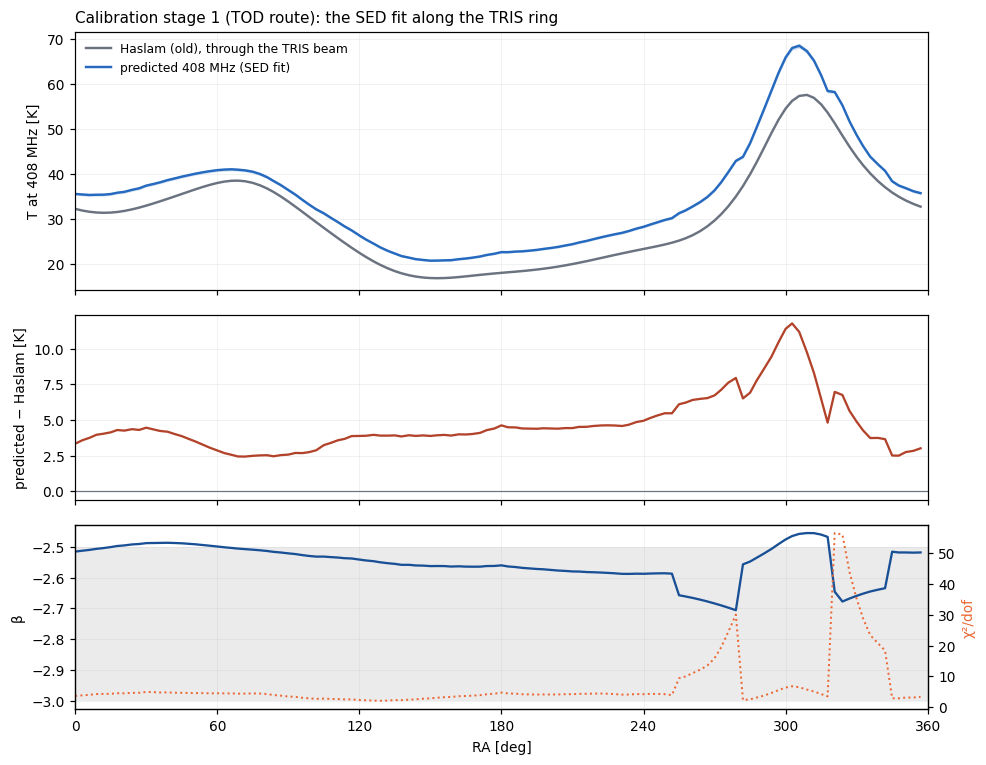

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[1.4, 1, 1], hspace=0.12))
ax = axes[0]
ax.plot(RA, HASLAM_TOD, "-", color="#6b7280", lw=1.6, label="Haslam (old), through the TRIS beam")
ax.plot(RA, TOD_PRED, "-", color="#256abf", lw=1.6, label="predicted 408 MHz (SED fit)")
ax.fill_between(RA, TOD_PRED - TOD_PRED_SIG, TOD_PRED + TOD_PRED_SIG, color="#256abf", alpha=0.2, lw=0)
ax.set_ylabel("T at 408 MHz [K]"); ax.legend(fontsize=8, frameon=False)
axes[1].plot(RA, TOD_DELTA, "-", color="#b2432a", lw=1.5)
axes[1].axhline(0, color="#6b7280", lw=0.8)
axes[1].set_ylabel("predicted − Haslam [K]")
axes[2].plot(RA, TOD_BETA, "-", color="#184f95", lw=1.5, label="β")
axes[2].axhspan(-3.0, -2.5, color="0.92", lw=0, zorder=0)
ax2 = axes[2].twinx()
ax2.plot(RA, TOD_CHI2, ":", color="#eb6834", lw=1.3, label="χ²/dof")
axes[2].set_ylabel("β"); ax2.set_ylabel("χ²/dof", color="#eb6834")
axes[2].set_xlabel("RA [deg]")
for a in axes:
    a.set_xlim(0, 360); a.set_xticks(np.arange(0, 361, 60)); a.grid(alpha=0.18, lw=0.6)
axes[0].set_title("Calibration stage 1 (TOD route): the SED fit along the TRIS ring", loc="left", fontsize=10)
plt.show()

### From the corrected TOD to a map

The correction TOD $\Delta_t$ = predicted − Haslam is turned into a map with stage 1's own
TOD → map machinery: limTOD's `wiener_filter_map`, with the **same** beam operator stage 1
builds for the ring (`build_tris_mapmaking_inputs`, sky columns only), over the TRIS stripe
pixels. The noise is the fit's σ per sample. The prior on the correction has **zero mean**:
where the ring says nothing, the correction falls to zero. Its width is 10% of old Haslam
⊕ 0.91 K (`CORRECTION_PRIOR`), loose against Haslam's ~3% / 0.91 K calibration
uncertainty. The corrected map is old Haslam + the correction map.

In [7]:
inputs = tris.build_tris_mapmaking_inputs(
    RINGS[600], nside=NSIDE, pixel_indices=stage1.pixel_indices, cuts=CUTS,
    uncertainty_floor_k=0.004, zero_level_sigma_k=float(config.require("tris.zero_level_sigma_k")),
    apply_horizon_mask=bool(config.require("beam.apply_horizon_mask")), nside_hires=HIRES)
B = np.asarray(inputs.operator)[:, :-1]                # sky columns; drop the zero level
pix = stage1.pixel_indices
old_in_band = OLD_HASLAM[pix]
prior_sigma = np.hypot(CORRECTION_PRIOR[0] * old_in_band, CORRECTION_PRIOR[1])
ok = np.isfinite(TOD_DELTA) & np.isfinite(TOD_PRED_SIG) & (TOD_PRED_SIG > 0)
delta_band, delta_sigma = wiener_filter_map(
    TOD_DELTA[ok], B[ok], noise_variance=TOD_PRED_SIG[ok] ** 2,
    prior_inv_cov=prior_sigma ** -2.0, guess=np.zeros(pix.size))

TOD_DELTA_MAP = np.full(hp.nside2npix(NSIDE), np.nan); TOD_DELTA_MAP[pix] = delta_band
TOD_CORRECTED = np.full(hp.nside2npix(NSIDE), np.nan); TOD_CORRECTED[pix] = old_in_band + delta_band
reproduced = B[ok] @ delta_band
print(f"correction map over {pix.size} stripe pixels: median {np.median(delta_band):+.2f} K, "
      f"range {delta_band.min():+.2f} to {delta_band.max():+.2f} K")
print(f"the map reproduces the correction TOD to rms {np.std(reproduced - TOD_DELTA[ok]):.3f} K "
      f"(TOD rms {np.std(TOD_DELTA[ok]):.3f} K); median σ of the correction map "
      f"{np.median(delta_sigma):.2f} K vs prior {np.median(prior_sigma):.2f} K")

correction map over 1272 stripe pixels: median +1.53 K, range +0.01 to +20.14 K
the map reproduces the correction TOD to rms 0.516 K (TOD rms 1.924 K); median σ of the correction map 2.91 K vs prior 2.93 K


---
## 4. Calibration stage 2 — the map route, pixel by pixel

At every TRIS-stripe pixel, the fit uses TRIS 600 and 820 (stage 1 `sky_k` + ẑ) plus every
map that has a value there on the TRIS grid. Most pixels have LWA, Maipu and Stockert;
ARCADE 2, CHIPASS and Rhodes only cover parts of the stripe.

In [8]:
TRIS_MAP = {}
for f in (600, 820):
    i = stage1.index(f)
    nu = float(stage1["effective_freq_mhz"][i])
    t = stage1.band_map("sky_k", f) + float(stage1["zero_level_k"][i])
    s = np.hypot(stage1.band_map("sky_sigma_k", f), float(stage1["zero_level_sigma_k"][i]))
    TRIS_MAP[nu] = (t - sky_maps.cmb_rj_k(nu), s)

MAP_PRED = np.full(hp.nside2npix(NSIDE), np.nan)
MAP_BETA, MAP_CHI2, MAP_N = (np.full(hp.nside2npix(NSIDE), np.nan) for _ in range(3))
dropped_negative = 0
for p in np.flatnonzero(BAND):
    nus, ts, ss = [], [], []
    for nu, (t, s) in TRIS_MAP.items():
        nus.append(nu); ts.append(t[p]); ss.append(s[p])
    for m in FIT_MAPS:
        v = GRID[m["name"]][p]
        if np.isfinite(v):
            t_ex = float(sky_maps.rj_excess(v, m))
            nus.append(m["freq_mhz"]); ts.append(t_ex); ss.append(float(sigma_for(m, t_ex)))
    dropped_negative += int(np.sum(np.array(ts) <= 0))
    r = fit(np.array(nus), np.array(ts), np.array(ss))
    if r:
        MAP_PRED[p], MAP_BETA[p] = r[0] + CMB408, r[1]
        MAP_CHI2[p], MAP_N[p] = r[3] / max(r[4] - 2, 1), r[4]

MAP_DELTA = MAP_PRED - OLD_HASLAM
MAP_CORRECTED = np.where(BAND, MAP_PRED, np.nan)
HYBRID = np.where(BAND & np.isfinite(MAP_PRED), MAP_PRED, OLD_HASLAM)
inb = BAND & np.isfinite(MAP_PRED)
print(f"{int(inb.sum())} of {int(BAND.sum())} stripe pixels fitted; points per pixel "
      f"{int(np.nanmin(MAP_N))}–{int(np.nanmax(MAP_N))}; {dropped_negative} non-positive points dropped")
print(f"median β {np.nanmedian(MAP_BETA):+.3f}; median χ²/dof {np.nanmedian(MAP_CHI2):.2f} "
      f"({100 * np.mean(MAP_CHI2[inb] <= 3):.0f}% of pixels ≤ 3)")
print(f"predicted − Haslam: median {np.nanmedian(MAP_DELTA[inb]):+.2f} K "
      f"({100 * np.nanmedian(MAP_DELTA[inb] / OLD_HASLAM[inb]):+.1f}%)")

1272 of 1272 stripe pixels fitted; points per pixel 5–10; 0 non-positive points dropped
median β -2.598; median χ²/dof 1.48 (89% of pixels ≤ 3)
predicted − Haslam: median +0.27 K (+0.9%)


---
## 5. The maps

All nside 16, equatorial, old and corrected on one colour scale. Grey: no value.

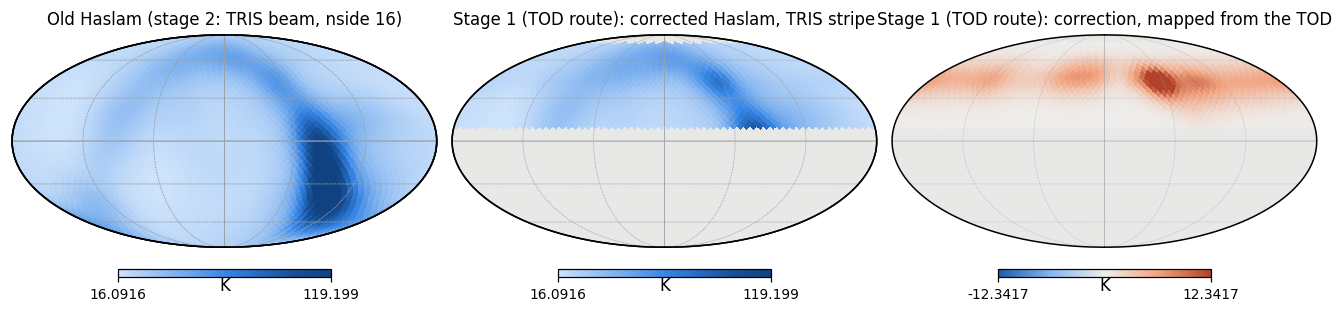

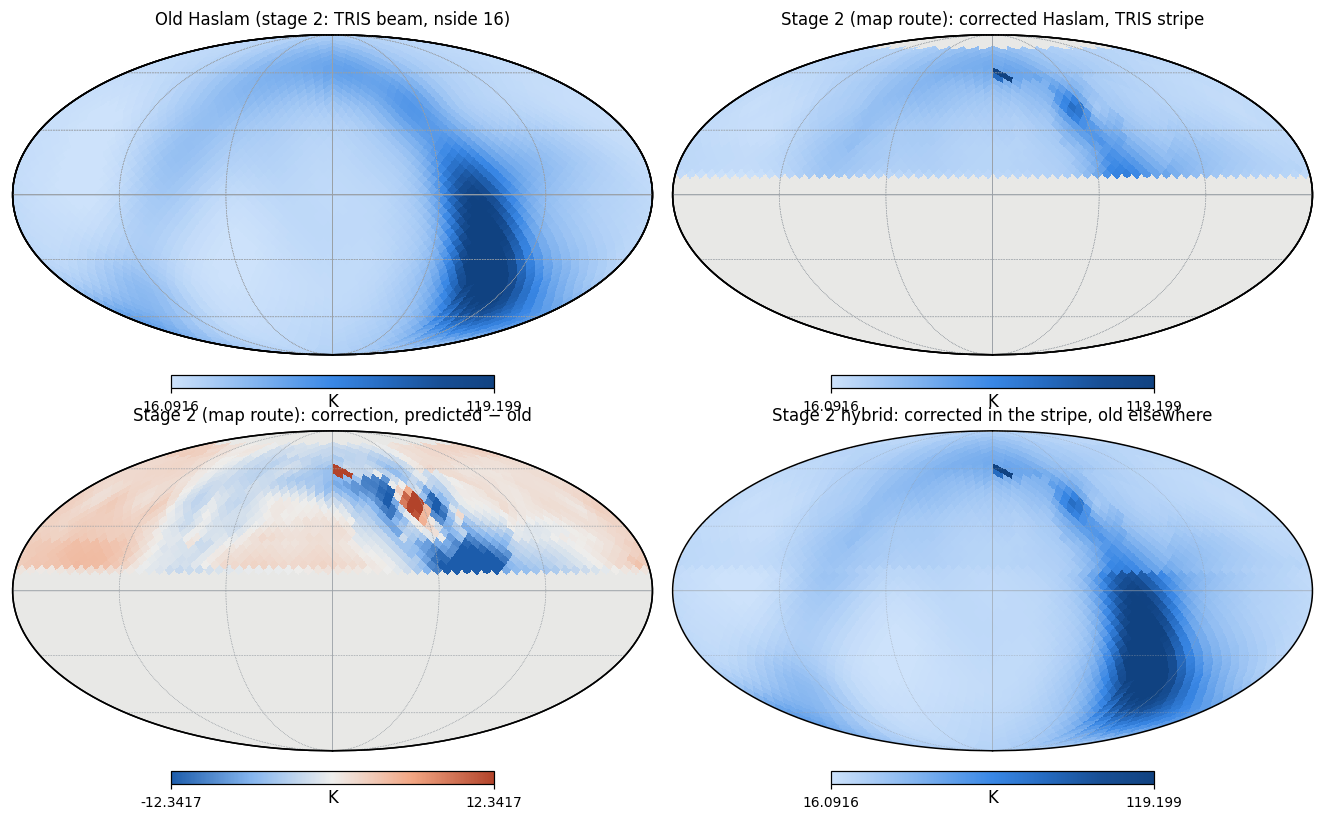

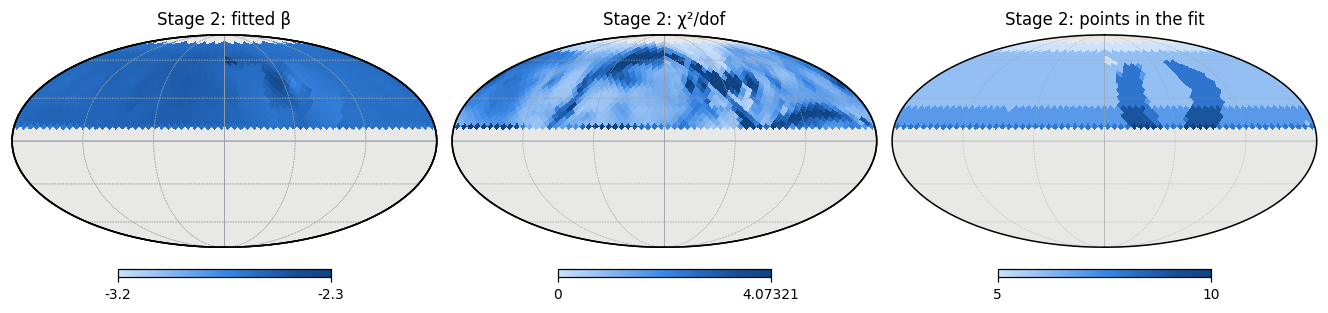

In [9]:
lo, hi = np.nanpercentile(OLD_HASLAM, [2, 98])
span = float(np.nanpercentile(np.abs(np.concatenate([TOD_DELTA_MAP[BAND], MAP_DELTA[inb]])), 98))
kw = dict(coord="C", notext=True, badcolor="#e8e8e6")

panels = [
    ("Old Haslam (stage 2: TRIS beam, nside 16)", OLD_HASLAM, SEQ, lo, hi, "K"),
    ("Stage 1 (TOD route): corrected Haslam, TRIS stripe", TOD_CORRECTED, SEQ, lo, hi, "K"),
    ("Stage 1 (TOD route): correction, mapped from the TOD", TOD_DELTA_MAP, DIV, -span, span, "K"),
]
fig = plt.figure(figsize=(12, 3.8))
for k, (title, m, cmap, a, b, unit) in enumerate(panels):
    hp.mollview(m, sub=(1, 3, k + 1), fig=fig.number, title=title, cmap=cmap, min=a, max=b,
                unit=unit, **kw)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
plt.show()

fig = plt.figure(figsize=(12, 7.2))
panels2 = [
    ("Old Haslam (stage 2: TRIS beam, nside 16)", OLD_HASLAM, SEQ, lo, hi),
    ("Stage 2 (map route): corrected Haslam, TRIS stripe", MAP_CORRECTED, SEQ, lo, hi),
    ("Stage 2 (map route): correction, predicted − old", np.where(inb, MAP_DELTA, np.nan), DIV, -span, span),
    ("Stage 2 hybrid: corrected in the stripe, old elsewhere", HYBRID, SEQ, lo, hi),
]
for k, (title, m, cmap, a, b) in enumerate(panels2):
    hp.mollview(m, sub=(2, 2, k + 1), fig=fig.number, title=title, cmap=cmap, min=a, max=b,
                unit="K", **kw)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
plt.show()

fig = plt.figure(figsize=(12, 3.8))
for k, (title, m, cmap, a, b) in enumerate([
        ("Stage 2: fitted β", MAP_BETA, SEQ, -3.2, -2.3),
        ("Stage 2: χ²/dof", MAP_CHI2, SEQ, 0, float(np.nanpercentile(MAP_CHI2, 95))),
        ("Stage 2: points in the fit", MAP_N, SEQ, float(np.nanmin(MAP_N)), float(np.nanmax(MAP_N)))]):
    hp.mollview(m, sub=(1, 3, k + 1), fig=fig.number, title=title, cmap=cmap, min=a, max=b, **kw)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
plt.show()

---
## 6. The two routes against each other, and against the benchmarks

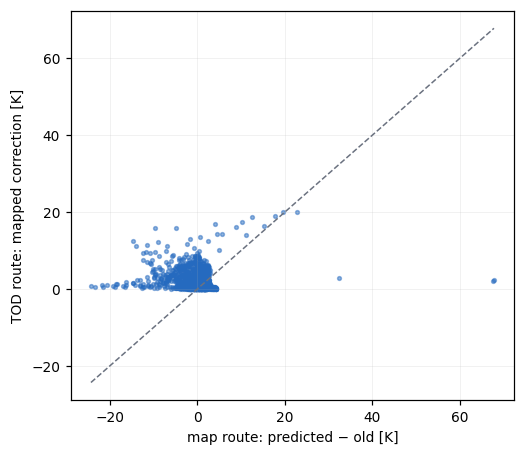

correlation of the two routes' corrections over the stripe: 0.03
              median Δ [K]  median Δ/old
TOD route             1.53          4.9%
map route             0.27          0.9%
benchmarks: Haslam scale uncertainty ~3%, zero level ~0.91 K


In [10]:
both = BAND & np.isfinite(TOD_DELTA_MAP) & np.isfinite(MAP_DELTA)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(MAP_DELTA[both], TOD_DELTA_MAP[both], s=6, color="#256abf", alpha=0.5)
lim = [np.nanmin([MAP_DELTA[both], TOD_DELTA_MAP[both]]), np.nanmax([MAP_DELTA[both], TOD_DELTA_MAP[both]])]
ax.plot(lim, lim, "--", color="#6b7280", lw=1)
ax.set_xlabel("map route: predicted − old [K]"); ax.set_ylabel("TOD route: mapped correction [K]")
ax.grid(alpha=0.18, lw=0.6)
plt.show()

scale, zero = float(config.require("validate.gain_scale_expected")), float(config.require("validate.zero_level_expected_k"))
print(f"correlation of the two routes' corrections over the stripe: {np.corrcoef(MAP_DELTA[both], TOD_DELTA_MAP[both])[0, 1]:.2f}")
print(f"{'':<12}{'median Δ [K]':>14}{'median Δ/old':>14}")
print(f"{'TOD route':<12}{np.nanmedian(TOD_DELTA_MAP[BAND]):14.2f}{100 * np.nanmedian(TOD_DELTA_MAP[BAND] / OLD_HASLAM[BAND]):13.1f}%")
print(f"{'map route':<12}{np.nanmedian(MAP_DELTA[inb]):14.2f}{100 * np.nanmedian(MAP_DELTA[inb] / OLD_HASLAM[inb]):13.1f}%")
print(f"benchmarks: Haslam scale uncertainty ~{100 * scale:.0f}%, zero level ~{zero} K")

---
## Reading the results

**The two routes disagree, and the reason is the TRIS input, not the fit.**

* **The TOD route** fits to the **real TRIS ring**, which is independent of Haslam. Along
  the ring, the predicted 408 MHz sky is above Haslam at every sample: median **+4.2 K
  (+18%)**, rising to ~12 K at the Cygnus crossing. This agrees with `notebooks/01` §06,
  where Haslam alone gives β ≈ −2.1 against TRIS 600. Mapped onto the stripe, the
  correction is strongest on the ring's declination and falls toward zero (the prior) away
  from it. The correction map's σ is barely below its prior except near the ring: 120
  samples constrain one declination.
* **The map route** fits to **stage 1's TRIS maps**, which are mostly the GSM2008 prior
  (the data narrowed only 23 of 1272 pixels by more than 5%). GSM2008 is built partly
  from Haslam, so this route largely compares Haslam with an extrapolation of Haslam.
  It finds a median of **+0.3 K**, with a ± pattern along the plane that comes from stage 1's
  pixel-scale structure. Its agreement with Haslam is **circular** (`prior_equals_truth`
  in the stage 1 manifest), not a measurement.
* **The two corrections correlate at ~0** over the stripe.

**What follows.** As things stand, the only Haslam-independent calibration signal is the
ring itself, which is the TOD route. The map route becomes meaningful only once stage 1's
prior is Haslam-independent (Berkhuijsen 1972, `TODO.md` B1/B2), or its TRIS values are
replaced by something data-driven.

* **χ²/dof** is high in the TOD route (median ~4, and up to ~50 where ARCADE 2 joins at
  RA 255–340°). One power law across 35 MHz to 3.4 GHz is in tension: the low-frequency
  surveys are flatter (β ≈ −2.5) than TRIS-to-ARCADE (β ≈ −2.85). Five surveys' error bars
  are an assumed 10%, so χ² is indicative only.
* **Neither route is the calibration yet.** Stage 4 still has to choose the error model
  (scale, offset or both) and fit it to these corrections.